# Dataset Preparation

- input: curated briefsummary
- output: pd.series of ase objects pr pymatgen objects


In [1]:
import sys
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
import os
import pandas as pd
from BopFoxFeaturizer.Featurizer import Featurizer
from Tools.DatasetTools.Tools import need_to_update
from Tools.DatasetTools.SublatticeSorter import *
from pymatgen.io.ase import AseAtomsAdaptor

# options 

In [2]:
dataset = 'Cr-Co-W'
case='POSCAR-initial' #, 'POSCAR-relaxed']
rescale_by_atoms=True #, False]
subcase = 'rescaled' # ,  'noscaled' ] 
Force= True
CuratedBS = os.path.join(dataset,'CuratedParsedBriefSummary.pkl')

In [3]:
BS = pd.read_pickle(CuratedBS)

In [4]:
Features = Featurizer(BS)

chech that the chemistry resetting is correct!

# Sort Poscar files

In [5]:
searchs = 'POSCAR.initial'

In [6]:
files = get_file_paths(dataset, searchs)

In [8]:
SORTERS, SUBLATICETAGS = get_all_sorters_and_tags(dataset, files)
SORTERS.to_pickle(os.path.join(dataset, 'SORTERS.pkl'))
SUBLATICETAGS.to_pickle(os.path.join(dataset, 'SUBLATICETAGS.pkl'))

100%|██████████| 1850/1850 [01:06<00:00, 27.90it/s]


# Now I have to pick the atoms objects

In [10]:
#for thiscase, (thisrescale, thissubcase) in product(case, zip(rescale_by_atoms, subcase)):
database = f'{dataset}/**/{case}'
AtomsFile = os.path.join(dataset,f'CrCoW-sorted-{case}-{subcase}-AtomsObjects.pkl')

In [13]:
if not need_to_update(AtomsFile):  #os.path.exists(AtomsFile) and not Force:
    Atoms_Objects = pd.read_pickle(AtomsFile)
else:
    Atoms_Objects, CantMake_Atoms_Object = Features.get_atoms_object(database=database,rescale_by_atoms=True, reset_chemistry=True, file_filter = 'sorted')
    Atoms_Objects.to_pickle(AtomsFile)
Atoms_Objects.dropna(inplace=True)
pymatgenfile = AtomsFile.replace('AtomsObjects','PymatgenStructures')
Pymatgen_Structures = Atoms_Objects.copy()
if not need_to_update(pymatgenfile):
    Pymatgen_Structures = pd.read_pickle(pymatgenfile)
else:
    Pymatgen_Structures = Atoms_Objects['atoms'].apply(AseAtomsAdaptor.get_structure)
    Pymatgen_Structures['file'] = Atoms_Objects['file']
    Pymatgen_Structures.to_pickle(pymatgenfile)

100%|█████████████████████████████████████████████████████████████████████████████████████████| 1701/1701 [01:03<00:00, 26.60it/s]


In [14]:
accomodatewrap = Atoms_Objects.atoms.map(lambda a: a.wrap(pretty_translation=True))

In [16]:
Atoms_Objects[Atoms_Objects.atoms.isna()==True]

,atoms,file


In [17]:
Atoms_Objects

,atoms,file
Co_pv6W_sv6.C14-BBA.FM,"(Atom('Co', [2.2140135370609073, 1.27826074118...",[Cr-Co-W/data/Co_pv-W_sv/POSCAR-initial/C14-BB...
Co_pv6W_sv6.C14-BBA.NM,"(Atom('Co', [2.2140135370609073, 1.27826074118...",[Cr-Co-W/data/Co_pv-W_sv/POSCAR-initial/C14-BB...
Cr_pv6W_sv2.D0_19-A3B.FM,"(Atom('Cr', [-0.43112800154619224, 2.239330855...",[Cr-Co-W/data/Cr_pv-W_sv/POSCAR-initial/D0_19-...
Cr_pv6W_sv2.D0_19-A3B.NM,"(Atom('Cr', [-0.43112800154619224, 2.239330855...",[Cr-Co-W/data/Cr_pv-W_sv/POSCAR-initial/D0_19-...
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,"(Atom('Cr', [5.541226311581246, 2.693413408415...",[Cr-Co-W/data/Cr_pv-Co_pv-W_sv/POSCAR-initial/...
...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,"(Atom('Cr', [0.17444091391996086, 1.3746733531...",[Cr-Co-W/data/Cr_pv-W_sv/POSCAR-initial/mu-BAA...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,"(Atom('Cr', [5.007611988807291, 5.007611988807...",[Cr-Co-W/data/Cr_pv-Co_pv-W_sv/POSCAR-initial/...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,"(Atom('Cr', [5.007611988807291, 5.007611988807...",[Cr-Co-W/data/Cr_pv-Co_pv-W_sv/POSCAR-initial/...
Co_pv13W_sv16.chi-ABAB.NM,"(Atom('Co', [1.657374720890617, 1.657374720890...",[Cr-Co-W/data/Co_pv-W_sv/POSCAR-initial/chi-AB...


In [18]:
Pymatgen_Structures[Pymatgen_Structures.isna()==True]

Series([], Name: atoms, dtype: object)

#  visualization of some structures

In [19]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rc('axes.spines', bottom=False, top=False, right=False, left=False)

In [20]:
from ase.visualize.plot import plot_atoms

In [21]:
Atoms_Objects

,atoms,file
Co_pv6W_sv6.C14-BBA.FM,"(Atom('Co', [2.2140135370609073, 1.27826074118...",[Cr-Co-W/data/Co_pv-W_sv/POSCAR-initial/C14-BB...
Co_pv6W_sv6.C14-BBA.NM,"(Atom('Co', [2.2140135370609073, 1.27826074118...",[Cr-Co-W/data/Co_pv-W_sv/POSCAR-initial/C14-BB...
Cr_pv6W_sv2.D0_19-A3B.FM,"(Atom('Cr', [-0.43112800154619224, 2.239330855...",[Cr-Co-W/data/Cr_pv-W_sv/POSCAR-initial/D0_19-...
Cr_pv6W_sv2.D0_19-A3B.NM,"(Atom('Cr', [-0.43112800154619224, 2.239330855...",[Cr-Co-W/data/Cr_pv-W_sv/POSCAR-initial/D0_19-...
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,"(Atom('Cr', [5.541226311581246, 2.693413408415...",[Cr-Co-W/data/Cr_pv-Co_pv-W_sv/POSCAR-initial/...
...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,"(Atom('Cr', [0.17444091391996086, 1.3746733531...",[Cr-Co-W/data/Cr_pv-W_sv/POSCAR-initial/mu-BAA...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,"(Atom('Cr', [5.007611988807291, 5.007611988807...",[Cr-Co-W/data/Cr_pv-Co_pv-W_sv/POSCAR-initial/...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,"(Atom('Cr', [5.007611988807291, 5.007611988807...",[Cr-Co-W/data/Cr_pv-Co_pv-W_sv/POSCAR-initial/...
Co_pv13W_sv16.chi-ABAB.NM,"(Atom('Co', [1.657374720890617, 1.657374720890...",[Cr-Co-W/data/Co_pv-W_sv/POSCAR-initial/chi-AB...


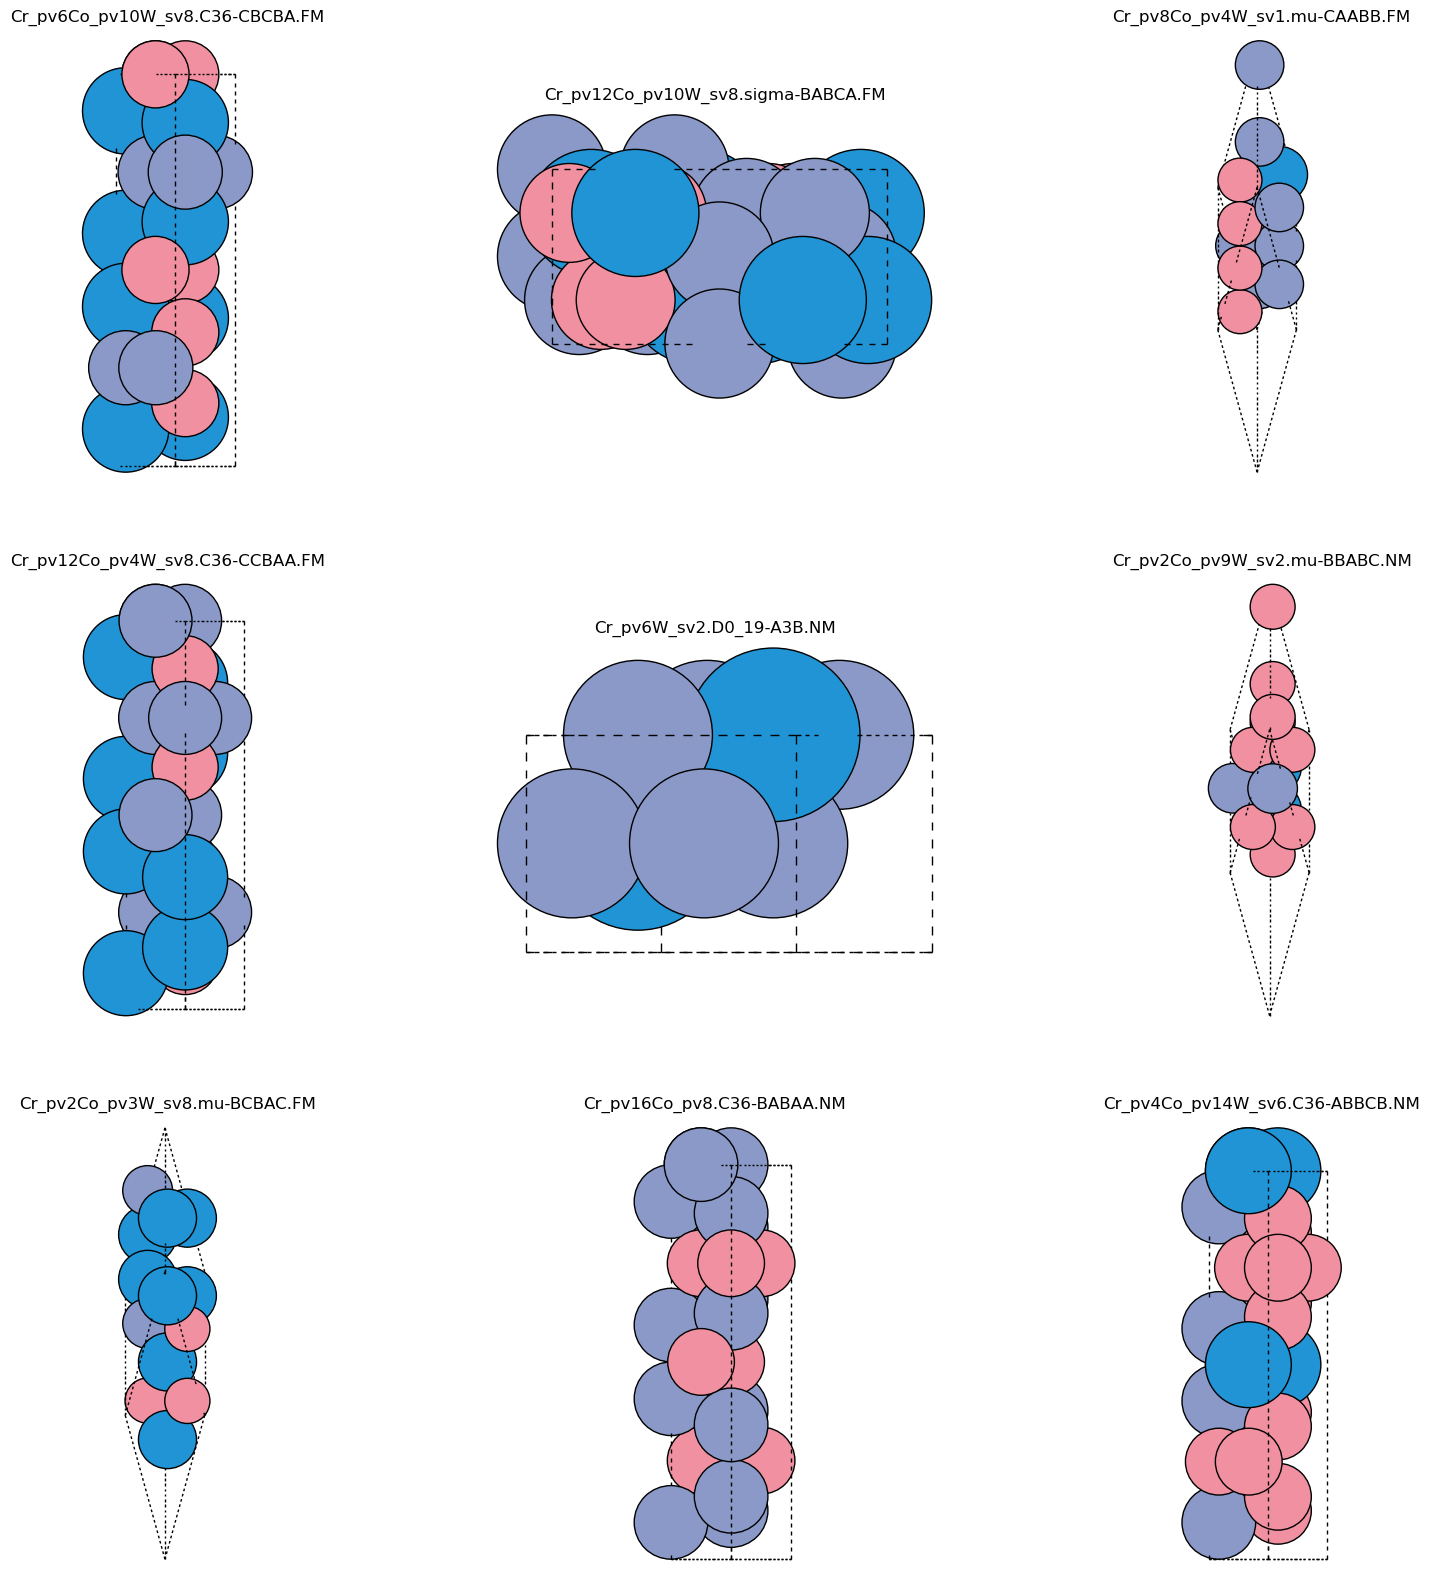

In [22]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, atoms_samples.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation = '90x')
#    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

In [23]:
somesigmas = Atoms_Objects.atoms[Atoms_Objects.index.str.contains('sigma')].sample(n=9)

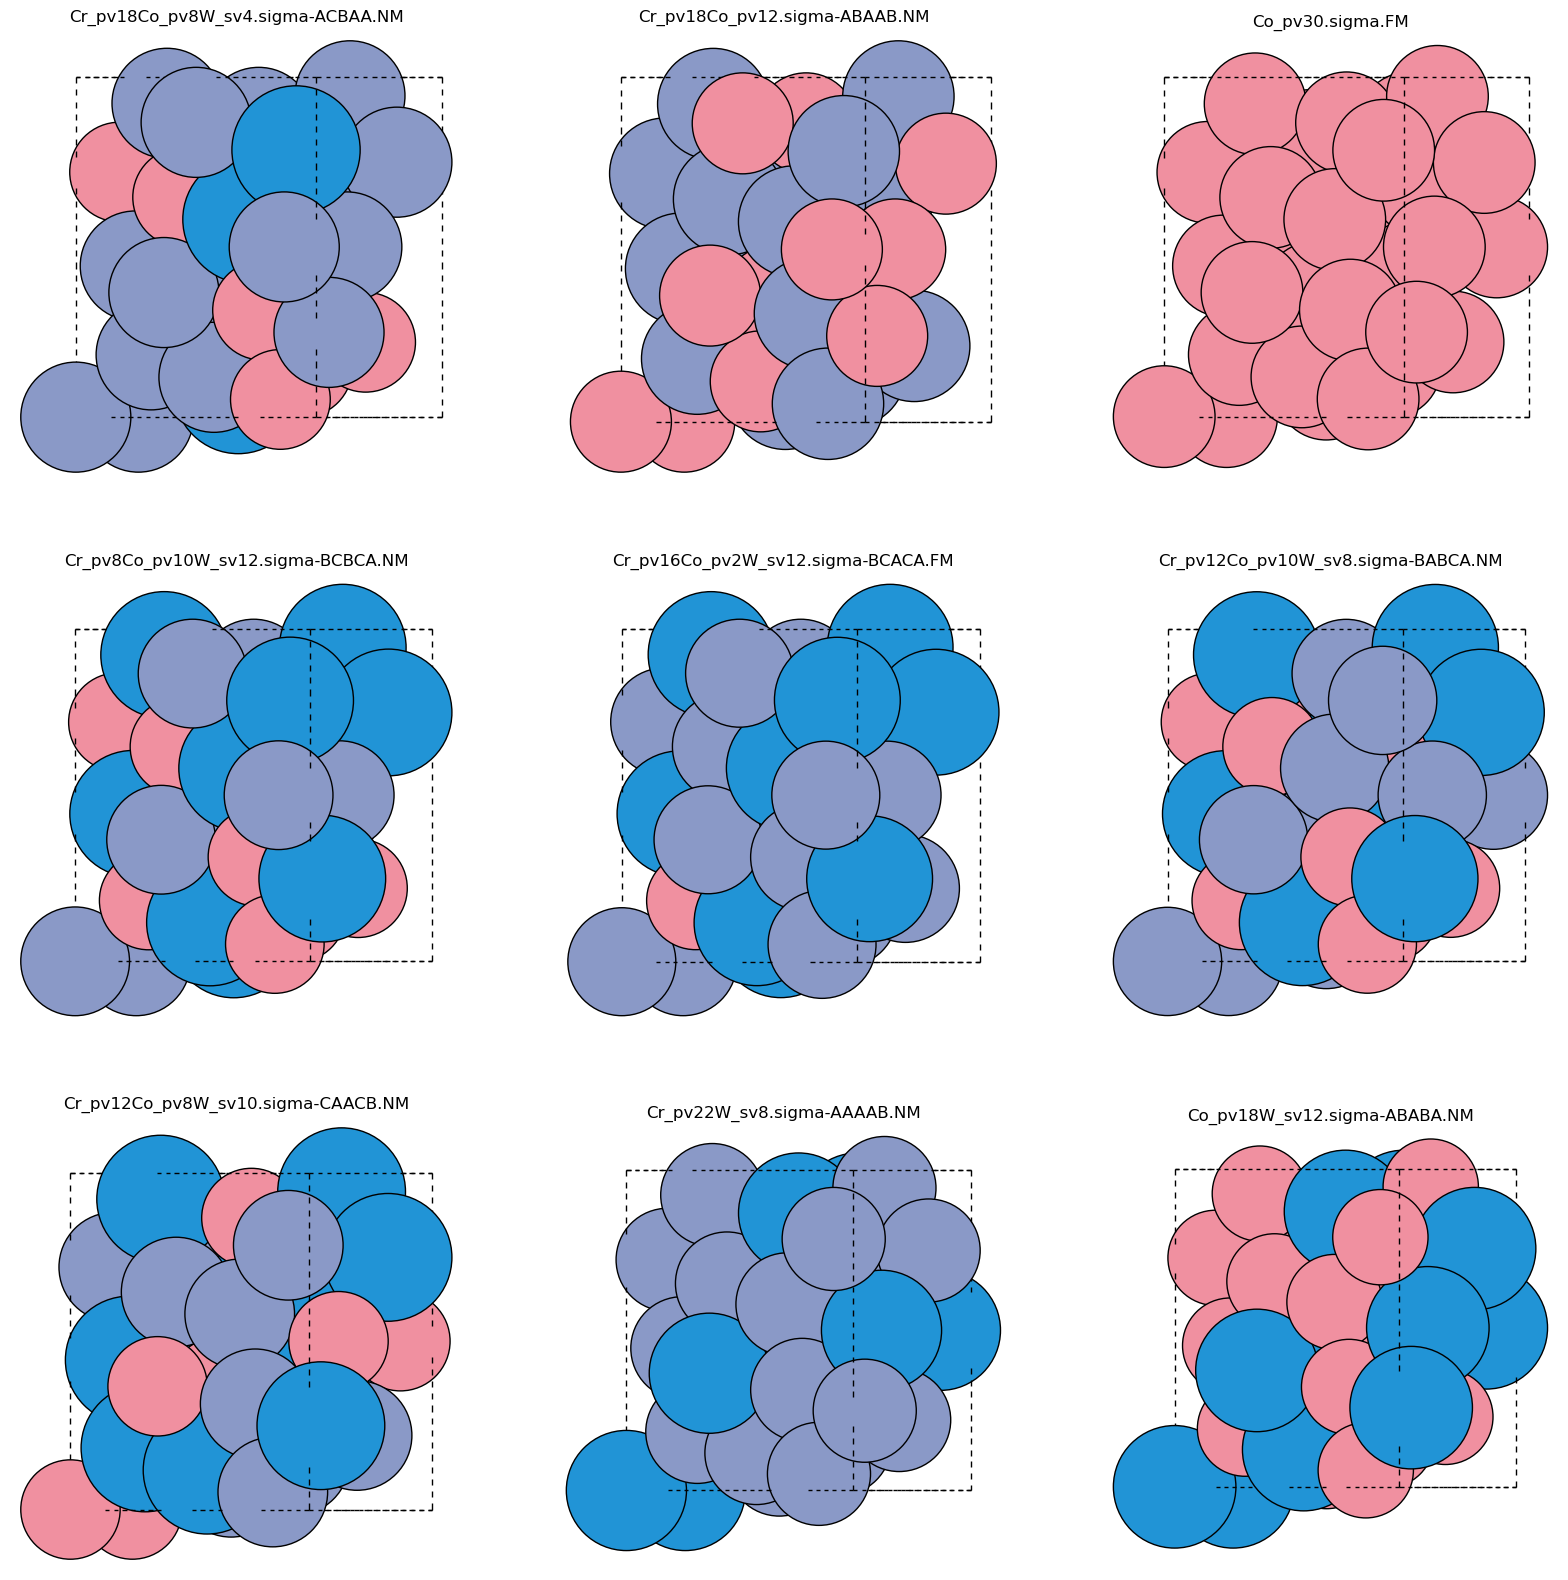

In [24]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, somesigmas.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation='90y, 90x, 45y')
    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

 For the actual visualization of the structures, we should choose one example for each structure and then draw in Vesta or Ovito for good quality figures, including coordination polyhedra etc.